In [1]:
# Unconditional Sampling Notebook for Guided Diffusion

import os
import torch
import random
import numpy as np
import matplotlib.pyplot as plt
import torchvision
from torchvision.utils import make_grid

from guided_diffusion import dist_util
from guided_diffusion.script_util import (
    model_and_diffusion_defaults,
    create_guided_model_and_diffusion,
)
from guided_diffusion.image_datasets import load_data
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
seed = 42

# Set Python, NumPy, and PyTorch seeds
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

# If using CUDA:
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True  # For reproducibility
    torch.backends.cudnn.benchmark = False


[csic41:224390] mca_base_component_repository_open: unable to open mca_btl_openib: librdmacm.so.1: cannot open shared object file: No such file or directory (ignored)


In [2]:

# ==== CONFIG ====
# checkpoint_path = "/home/rg625@ad.eng.cam.ac.uk/models/conditional/cifar10/ema_0.9999_200000.pt"
checkpoint_path = "/home/rg625@ad.eng.cam.ac.uk/models/conditional/cifar10/q500000.pt"
num_samples = 16
batch_size = 16
image_size = 32  # CIFAR10

# ==== Set up device ====
dist_util.setup_dist()

# ==== Load model and diffusion ====
model_args = model_and_diffusion_defaults()
model_args.update(
    dict(
        image_size=image_size,
        class_cond=False,
        unet_ckpt = "/home/rg625@ad.eng.cam.ac.uk/models/unconditional/cifar10/ema_0.9999_200000.pt"
    )
)
model, diffusion = create_guided_model_and_diffusion(**model_args)
model.load_state_dict(torch.load(checkpoint_path, map_location="cpu"))
model.to(dist_util.dev())
model.eval()
model.sampling = True

Loading pretrained weights from /home/rg625@ad.eng.cam.ac.uk/models/unconditional/cifar10/ema_0.9999_200000.pt, step: N/A


In [3]:
data = load_data(
        data_dir="/home/rg625@ad.eng.cam.ac.uk/datasets/cifar10/images/",
        batch_size=batch_size,
        image_size=image_size,
        class_cond=False,
    )

In [4]:
# ==== Sampling function ====
def sample(model, cond_fn, num_samples, noise, model_kwargs):
    samples = diffusion.p_sample_loop(
        model=model,
        shape=(num_samples, 3, image_size, image_size),
        noise=noise,
        clip_denoised=True,
        cond_fn=cond_fn,
        model_kwargs=model_kwargs,
        progress=True,
    )
    return (samples + 1) / 2  # from [-1,1] to [0,1]

In [5]:
# ==== Generate samples ====
noise = torch.randn((num_samples, 3, image_size, image_size), device = device, dtype=torch.float32, requires_grad=True)
x_start, cond = next(data)
x_start.requires_grad_(True)
sample_unconditional = sample(
    model.unet_model, 
    cond_fn=None, 
    num_samples=num_samples, 
    noise=noise,
    model_kwargs = {},
    )

z = model.prepare_for_sampling(x_0=x_start.to(device))
z["encoding"] = z["encoding"].detach().clone().requires_grad_(True)
def cond_fn(x, t):
    return model.guidance_score(x, t, z=z["encoding"])
# With guidance
sample_with_condfn = sample(
    model.unet_model, 
    cond_fn=cond_fn, 
    num_samples=num_samples, 
    noise=noise,
    model_kwargs = {},
)
# Without guidance (vanilla DDPM)
# sample_without_condfn = sample(
#     model,  # ScoreVAE acts like base model when cond_fn is None
#     cond_fn=None, 
#     num_samples=num_samples, 
#     noise=noise,
#     model_kwargs={
#         "z_start": z["encoding"].to(device),
#     },
# )

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


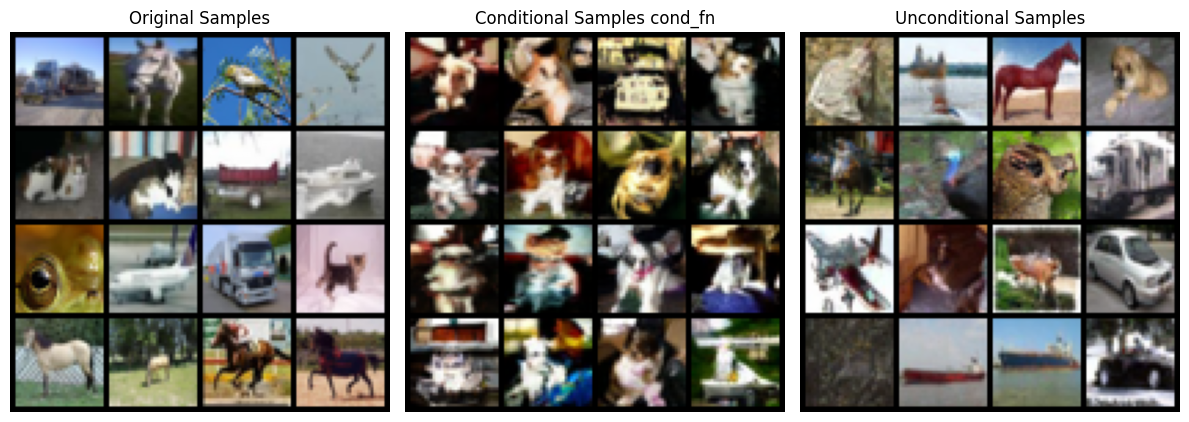

In [6]:
# ==== Visualize ====
# Create sample grids
grid_original = make_grid(x_start, nrow=4, normalize=True)
grid_unconditional = make_grid(sample_unconditional, nrow=4)
grid_with = make_grid(sample_with_condfn, nrow=4)
# grid_without = make_grid(sample_without_condfn, nrow=4)

# Plot side-by-side
plt.figure(figsize=(12, 6))

# Conditional samples
plt.subplot(1, 3, 1)
plt.imshow(grid_original.permute(1, 2, 0).cpu())
plt.axis("off")
plt.title("Original Samples")

# Conditional samples
plt.subplot(1, 3, 3)
plt.imshow(grid_unconditional.permute(1, 2, 0).cpu())
plt.axis("off")
plt.title("Unconditional Samples")

# Different conditional samples
plt.subplot(1, 3, 2)
plt.imshow(grid_with.permute(1, 2, 0).cpu())
plt.axis("off")
plt.title("Conditional Samples cond_fn")

# # Unconditional samples
# plt.subplot(1, 3, 3)
# plt.imshow(grid_without.permute(1, 2, 0).cpu())
# plt.axis("off")
# plt.title("Conditional Samples forward")

plt.tight_layout()
plt.show()

In [7]:
# prior_score = model.sample_encoding["prior_score"]
prior_score = diffusion.sample_encoding["prior_score"]
conditional_score_cond = diffusion.sample_encoding["conditional_score"]
# conditional_score_fw = model.sample_encoding["conditional_score"]
print(len(prior_score))
print(prior_score[0].shape)

prior_norm_cond = []
prior_norm_fw = []
conditional_norm_cond = []
conditional_norm_fw = []
for i in range(len(prior_score)//2):
    prior_norm_cond.append(torch.norm(prior_score[i]).detach().cpu().numpy()/((torch.norm(conditional_score_cond[i]).detach().cpu().numpy()+torch.norm(prior_score[i]).detach().cpu().numpy())))
    # prior_norm_fw.append(torch.norm(prior_score[i]).detach().cpu().numpy()/((torch.norm(conditional_score_fw[i]).detach().cpu().numpy()+torch.norm(prior_score[i]).detach().cpu().numpy()))) 
    conditional_norm_cond.append(torch.norm(conditional_score_cond[i]).detach().cpu().numpy()/((torch.norm(conditional_score_cond[i]).detach().cpu().numpy()+torch.norm(prior_score[i]).detach().cpu().numpy()))) 
    # conditional_norm_fw.append(torch.norm(conditional_score_fw[i]).detach().cpu().numpy()/((torch.norm(conditional_score_fw[i]).detach().cpu().numpy()+torch.norm(prior_score[i]).detach().cpu().numpy()))) 



2000
torch.Size([16, 3, 32, 32])


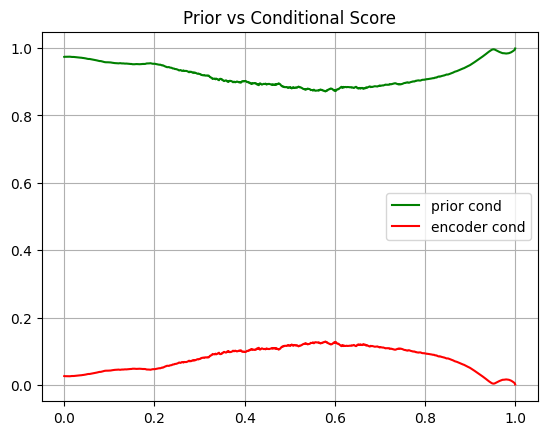

In [8]:
plt.plot(np.linspace(0., 1., len(prior_norm_cond)), prior_norm_cond, c='green', label='prior cond')
# plt.plot(np.linspace(0., 1., len(prior_norm_cond)), prior_norm_fw, c='blue', label='prior fw')
plt.plot(np.linspace(0., 1., len(prior_norm_cond)), conditional_norm_cond, c='red', label='encoder cond')
# plt.plot(np.linspace(0., 1., len(prior_norm_cond)), conditional_norm_fw, c='magenta', label='encoder fw')
plt.title('Prior vs Conditional Score')
plt.grid()
plt.legend()
plt.show()